<a href="https://colab.research.google.com/github/Shahidd7/credit-risk-prediction/blob/main/credit_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv')

In [5]:
df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19646,66441354,NaN,6000.0,6000.0,6000.0,36 months,6.24,183.19,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
19647,67345839,NaN,10000.0,10000.0,10000.0,36 months,8.38,315.12,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
19648,66423452,NaN,17000.0,17000.0,16850.0,36 months,15.41,592.73,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
19649,66550260,NaN,1000.0,1000.0,1000.0,36 months,14.48,34.42,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19651 entries, 0 to 19650
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 22.6+ MB


In [7]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,1.965100e+04,0.0,19651.000000,19651.000000,19651.000000,19651.000000,19651.000000,1.965100e+04,19650.000000,19651.000000,...,160.0,160.000000,160.0,160.000000,127.000000,160.000000,160.000000,575.000000,575.000000,575.000000
mean,6.765999e+07,NaN,15057.589945,15057.589945,15052.055875,12.249696,437.684287,7.843097e+04,19.408563,0.336624,...,3.0,133.773750,3.0,14.162500,401.123150,10823.932625,181.151875,4984.088574,47.195009,14.062609
std,1.918262e+06,NaN,8736.862265,8736.862265,8732.147683,4.205565,249.787658,6.083320e+04,11.295816,0.890156,...,0.0,111.231154,0.0,10.106283,328.034314,6597.651487,181.666255,3597.113370,5.273600,7.491894
min,3.617740e+05,NaN,1000.000000,1000.000000,1000.000000,5.320000,30.540000,0.000000e+00,0.000000,0.000000,...,3.0,5.280000,3.0,0.000000,33.840000,594.070000,0.060000,250.000000,30.000000,0.000000
25%,6.734874e+07,NaN,8000.000000,8000.000000,8000.000000,9.170000,255.040000,4.800000e+04,12.650000,0.000000,...,3.0,48.892500,3.0,5.000000,150.210000,5959.425000,47.445000,2077.025000,45.000000,8.000000
50%,6.771551e+07,NaN,14000.000000,14000.000000,14000.000000,11.990000,382.540000,6.700000e+04,18.810000,0.000000,...,3.0,102.855000,3.0,15.500000,320.520000,9526.755000,116.350000,4207.230000,45.000000,14.000000
75%,6.826254e+07,NaN,20000.000000,20000.000000,20000.000000,14.480000,582.300000,9.500000e+04,25.640000,0.000000,...,3.0,183.955000,3.0,23.250000,530.085000,15176.715000,265.820000,7174.400000,50.000000,18.000000
max,6.861706e+07,NaN,35000.000000,35000.000000,35000.000000,28.990000,1354.660000,3.964280e+06,999.000000,15.000000,...,3.0,629.700000,3.0,30.000000,1889.100000,28479.590000,780.050000,17500.000000,67.450000,36.000000


In [8]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [9]:
df.isnull().sum()

,0
id,0
member_id,19651
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
settlement_status,19076
settlement_date,19076
settlement_amount,19076
settlement_percentage,19076


In [10]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(f"Shape before cleaning: {df.shape}")

df = df.dropna(axis=1,how='all')

threshold = len(df) * 0.90
df = df.dropna(axis = 1, thresh=threshold)

print(f"Shape after cleaning: {df.shape}")


Shape before cleaning: (19651, 151)
Shape after cleaning: (19651, 105)


In [12]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19651 entries, 0 to 19650
Data columns (total 105 columns):
 #    Column                      Dtype  
---   ------                      -----  
 0    id                          int64  
 1    loan_amnt                   float64
 2    funded_amnt                 float64
 3    funded_amnt_inv             float64
 4    term                        object 
 5    int_rate                    float64
 6    installment                 float64
 7    grade                       object 
 8    sub_grade                   object 
 9    emp_title                   object 
 10   emp_length                  object 
 11   home_ownership              object 
 12   annual_inc                  float64
 13   verification_status         object 
 14   issue_d                     object 
 15   loan_status                 object 
 16   pymnt_plan                  object 
 17   url                         object 
 18   purpose                     object 
 19   ti

In [13]:
df.isnull().sum()

,0
id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
...,...
total_bc_limit,1
total_il_high_credit_limit,1
hardship_flag,1
disbursement_method,1


In [14]:
df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,...,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N


In [15]:
df.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title',
       ...
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object', length=105)

In [16]:
print('Original Loan Statuses:')
print(df['loan_status'].unique())

finished_statuses =['Fully Paid','Charged Off','Default']
df = df[df['loan_status'].isin(finished_statuses)].copy()

df['Target'] = df['loan_status'].apply(lambda x:1 if x in ['Charged Off','Default'] else 0)
df = df.drop(columns = ['loan_status'])


leaky_cols = [
    'id', 'url', 'funded_amnt_inv', 'pymnt_plan',
    'initial_list_status', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'debt_settlement_flag'
]
leaky_cols_present = [c for c in leaky_cols if c in df.columns]
df = df.drop(columns = leaky_cols_present)



Original Loan Statuses:
['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)']


In [17]:
print(f'Shape after Cleaning :{df.shape}')

print("\nTarget Class Distribution (0 = Good, 1 = Default):")
print(df['Target'].value_counts(normalize=True).round(4) * 100)

Shape after Cleaning :(17427, 84)

Target Class Distribution (0 = Good, 1 = Default):
Target
0    79.9
1    20.1
Name: proportion, dtype: float64


In [18]:
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,Target
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,...,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,...,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,...,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,0
4,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,...,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,0
5,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,...,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash,0


In [19]:
df['emp_length'].isnull().sum()

np.int64(1085)

In [20]:
df['issue_d'].unique()

array(['Dec-2015'], dtype=object)

In [21]:
if 'issue_d' in df.columns:
  df['issue_d'] = pd.to_datetime(df['issue_d'], format = '%b-%Y')

In [22]:
df['earliest_cr_line'].unique()

array(['Aug-2003', 'Dec-1999', 'Aug-2000', 'Jun-1998', 'Oct-1987',
       'Jun-1990', 'Feb-1999', 'Apr-2002', 'Nov-1994', 'Jun-1996',
       'Jun-2005', 'May-1984', 'Dec-2001', 'Nov-1993', 'Mar-2005',
       'May-2004', 'Jun-1991', 'May-2000', 'Oct-2011', 'May-1994',
       'Jul-2011', 'May-1991', 'May-2001', 'Jun-2002', 'Dec-1985',
       'Apr-2007', 'Feb-2002', 'Jun-2001', 'Oct-1996', 'Jan-2005',
       'Jul-2001', 'Aug-2004', 'Jun-2007', 'Jul-2004', 'Apr-2001',
       'May-1992', 'Oct-1999', 'Nov-2001', 'Jan-2001', 'Sep-2004',
       'Sep-2006', 'Oct-2002', 'Feb-1990', 'Aug-1987', 'Oct-1998',
       'Aug-2001', 'Feb-2004', 'Aug-2009', 'Jan-1999', 'Jun-2000',
       'Jan-2007', 'Aug-1997', 'Dec-1987', 'Feb-1996', 'Jun-2004',
       'Jun-1995', 'Oct-2004', 'Dec-2002', 'Aug-1986', 'Nov-2002',
       'Oct-2006', 'Sep-2000', 'Feb-2012', 'Apr-2005', 'Sep-1994',
       'Apr-1993', 'Sep-2007', 'Jan-1998', 'May-2008', 'Mar-2001',
       'Apr-1994', 'Apr-2003', 'Jan-2002', 'Jan-2011', 'Nov-20

In [23]:
if 'earliest_cr_line' in df.columns:
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format = '%b-%Y')

In [24]:
df['credit_hist_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25
df= df.drop(columns = ['earliest_cr_line'])


In [25]:
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [26]:
if 'term' in df.columns:
  df['term'] = df['term'].str.extract(r'(\d+)').astype(float)

In [27]:
df['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', nan],
      dtype=object)

In [28]:
if 'emp_length' in df.columns:
  emp_map ={
      '10+ years' :10,
      '9 years' :9,
      '8 years' :8,
      '7 years' :7,
      '6 years' :6,
      '5 years' :5,
      '4 years' :4,
      '3 years' :3,
      '2 years' :2,
      '1 years' :1,
      '< 1 year' :0,
  }
  df['emp_length'] = df['emp_length'].map(emp_map)


In [29]:
cat_cols = df.select_dtypes(include = 'object').columns.tolist()

for c in cat_cols:
  df[c] = df[c].astype('category')

In [30]:
print("Feature Engineering Complete!")
print(f"New shape: {df.shape}")
print("\nHere is a look at our cleaned numeric features:")
display(df[['term', 'emp_length', 'credit_hist_years']].head())

print(f"\nCategorical columns remaining (LightGBM will handle these automatically): \n{cat_cols}")

Feature Engineering Complete!
New shape: (17427, 84)

Here is a look at our cleaned numeric features:


,term,emp_length,credit_hist_years
0,36.0,10.0,12.334018
1,36.0,10.0,16.000000
2,60.0,10.0,15.331964
4,60.0,3.0,17.500342
5,36.0,4.0,28.167009



Categorical columns remaining (LightGBM will handle these automatically): 
['grade', 'sub_grade', 'emp_title', 'home_ownership', 'verification_status', 'purpose', 'title', 'zip_code', 'addr_state', 'application_type', 'disbursement_method']


In [31]:
noisy_cols = ['emp_title', 'url', 'title', 'zip_code']
df = df.drop(columns=[c for c in noisy_cols if c in df.columns])

In [32]:
for col in ['int_rate','revol_util']:
  if col in df.columns and df[col].dtype == 'object':
    df[col] = df[col].replace.stc('%','',regex = False).astype(float)

print("Bugs fixed and noisy columns dropped!")
print(f"Final shape before modeling: {df.shape}")
print("\nVerify our numeric features are actually numbers now:")
display(df[['term', 'int_rate', 'emp_length', 'revol_util']].head())

Bugs fixed and noisy columns dropped!
Final shape before modeling: (17427, 81)

Verify our numeric features are actually numbers now:


,term,int_rate,emp_length,revol_util
0,36.0,13.99,10.0,29.7
1,36.0,11.99,10.0,19.2
2,60.0,10.78,10.0,56.2
4,60.0,22.45,3.0,64.5
5,36.0,13.44,4.0,68.4


In [33]:
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,Target,credit_hist_years
0,3600.0,3600.0,36.0,13.99,123.03,C,C4,10.0,MORTGAGE,55000.0,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0,12.334018
1,24700.0,24700.0,36.0,11.99,820.28,C,C1,10.0,MORTGAGE,65000.0,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0,16.000000
2,20000.0,20000.0,60.0,10.78,432.66,B,B4,10.0,MORTGAGE,63000.0,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,0,15.331964
4,10400.0,10400.0,60.0,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,0,17.500342
5,11950.0,11950.0,36.0,13.44,405.18,C,C3,4.0,RENT,34000.0,...,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash,0,28.167009


In [34]:
df['issue_d'].value_counts()

,count
issue_d,
2015-12-01,17427


In [35]:
from sklearn.metrics import roc_auc_score,average_precision_score
import lightgbm as lgb

In [36]:
df_sorted = df.sort_values('issue_d').copy()

In [37]:
split_idx = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_idx].copy()
test_df = df_sorted.iloc[split_idx:].copy()

In [38]:
if 'issue_d' in train_df.columns:
    train_df = train_df.drop(columns=['issue_d'])
if 'issue_d' in test_df.columns:
    test_df = test_df.drop(columns=['issue_d'])

X_train,y_train = train_df.drop(columns =['Target']),train_df['Target']
X_test,y_test = test_df.drop(columns =['Target']),test_df['Target']

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train Default Rate: {y_train.mean()*100:.2f}% | Test Default Rate: {y_test.mean()*100:.2f}%")

Train shape: (13941, 79) | Test shape: (3486, 79)
Train Default Rate: 20.06% | Test Default Rate: 20.25%


In [39]:
neg,pos = np.bincount(y_train)
spw = neg/pos

print(f"Good Loan (0):{neg} | Bad Loan (1):{pos}")
print(f"Scale Pos Weight set to: {spw:.2f}")

Good Loan (0):11145 | Bad Loan (1):2796
Scale Pos Weight set to: 3.99


In [40]:
lgb_model = lgb.LGBMClassifier(
    n_estimators = 1000,
    learning_rate = 0.05,
    num_leaves = 31,
    scale_pos_weight = spw,
    random_state = 42,
    n_jobs = -1
)

cat_cols = X_train.select_dtypes('category').columns.tolist()

lgb_model.fit(X_train,y_train,
              eval_set = [(X_test,y_test)],
              eval_metric = 'average_precision',
              categorical_feature = cat_cols,
              callbacks = [
                  lgb.early_stopping(50,verbose=True,first_metric_only=True),
                  lgb.log_evaluation(50)
              ])

y_proba = lgb_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test,y_proba)

pr_auc = average_precision_score(y_test,y_proba)


print("\n--- Baseline Model Performance ---")
print(f"ROC-AUC: {roc:.4f} (Overall ranking ability)")
print(f"PR-AUC:  {pr_auc:.4f} (Performance on the minority class)")
print(f"Best Iteration: {lgb_model.best_iteration_} trees")

[LightGBM] [Info] Number of positive: 2796, number of negative: 11145
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004606 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7605
[LightGBM] [Info] Number of data points in the train set: 13941, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200560 -> initscore=-1.382801
[LightGBM] [Info] Start training from score -1.382801
Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.39075	valid_0's binary_logloss: 0.567306
[100]	valid_0's average_precision: 0.393851	valid_0's binary_logloss: 0.570301
Early stopping, best iteration is:
[59]	valid_0's average_precision: 0.394058	valid_0's binary_logloss: 0.572003
Evaluated only: average_precision

--- Baseline Model Performance ---
ROC-AUC: 0.7134 (Overall ranking ability)
P

KS Statistic: 0.3247

Mean predicted probability: 0.4099
Actual default rate in Test set: 0.2025


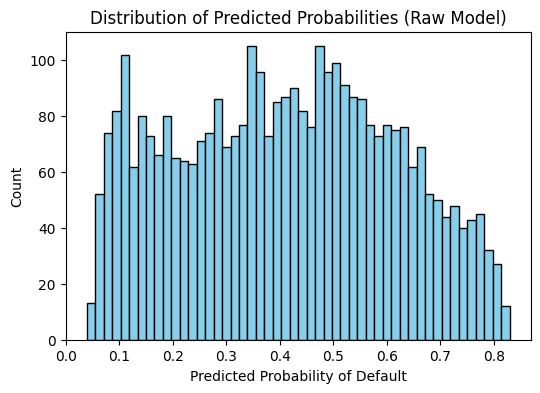

In [41]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate KS Statistic
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
ks_statistic = max(tpr - fpr)
print(f"KS Statistic: {ks_statistic:.4f}")

# 2. Let's look at the actual probabilities the model is outputting
print(f"\nMean predicted probability: {y_proba.mean():.4f}")
print(f"Actual default rate in Test set: {y_test.mean():.4f}")

# 3. Visualize how "uncalibrated" our probabilities are
plt.figure(figsize=(6, 4))
plt.hist(y_proba, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Predicted Probabilities (Raw Model)')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Count')
plt.show()

Sub-Train shape: (10455, 79) | Calibration shape: (3486, 79)
[LightGBM] [Info] Number of positive: 2097, number of negative: 8358
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7521
[LightGBM] [Info] Number of data points in the train set: 10455, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200574 -> initscore=-1.382711
[LightGBM] [Info] Start training from score -1.382711
Calibrating model...

--- After Calibration ---
Mean predicted probability: 0.2063
Actual default rate in Test set: 0.2025


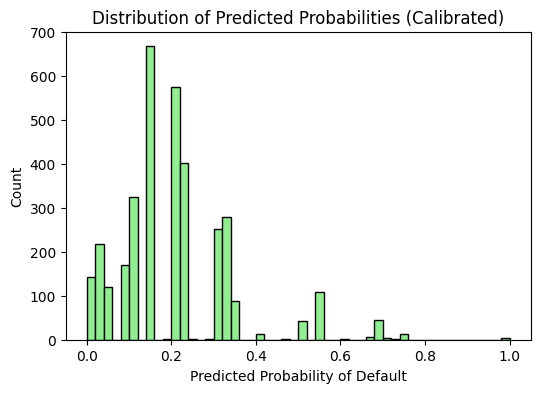

In [42]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. We need to split our Train set to create a Calibration set
# We train on 75% of the train set, and use 25% to calibrate probabilities
X_train_sub, X_calib, y_train_sub, y_calib = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

print(f"Sub-Train shape: {X_train_sub.shape} | Calibration shape: {X_calib.shape}")

# 2. Retrain the LightGBM model on the sub-train set
# (We use the same parameters as before)
cat_cols = X_train_sub.select_dtypes(include='category').columns.tolist()

lgb_sub = lgb.LGBMClassifier(
    n_estimators=222, # Use the best iteration we found earlier!
    learning_rate=0.05, num_leaves=31,
    scale_pos_weight=spw, random_state=42, n_jobs=-1
)
lgb_sub.fit(X_train_sub, y_train_sub, categorical_feature=cat_cols)

# 3. Apply Isotonic Calibration
print("Calibrating model...")
calibrated_model = CalibratedClassifierCV(lgb_sub, method='isotonic', cv='prefit')
calibrated_model.fit(X_calib, y_calib)

# 4. Predict on the Test set with the CALIBRATED model
y_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# 5. Let's check our new reality
print(f"\n--- After Calibration ---")
print(f"Mean predicted probability: {y_proba_calibrated.mean():.4f}")
print(f"Actual default rate in Test set: {y_test.mean():.4f}")

# 6. Visualize the new, calibrated probabilities
plt.figure(figsize=(6, 4))
plt.hist(y_proba_calibrated, bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of Predicted Probabilities (Calibrated)')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Count')
plt.show()

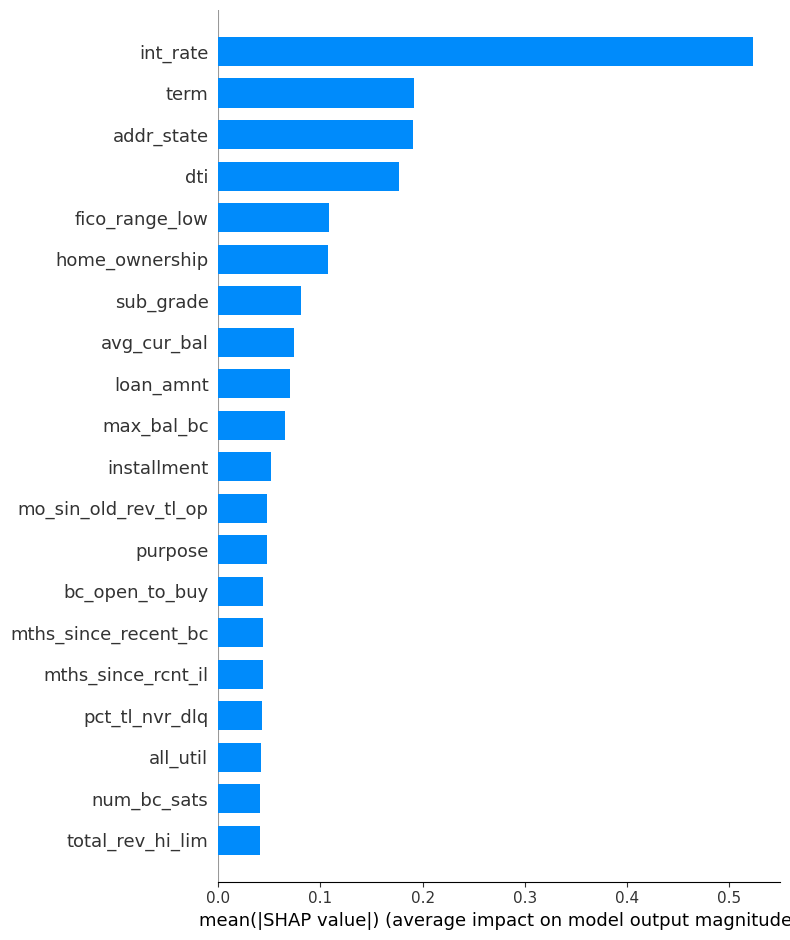

In [43]:
import shap

# 1. Create the SHAP Explainer using our trained LightGBM model
explainer = shap.TreeExplainer(lgb_sub)

# 2. Calculate SHAP values for the Test set
# We use the first 500 rows of the test set to make it run fast in Colab
X_test_sample = X_test.head(500)
shap_values = explainer.shap_values(X_test_sample)

# Note: In newer LightGBM versions, shap_values might return a list [negative, positive]
# We want the positive (default) class
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

# 3. Plot the Global Feature Importance
shap.summary_plot(shap_values_positive, X_test_sample, plot_type="bar")

Predicted Default Probability for Applicant #0: 32.60%
Actual Outcome (1=Default, 0=Paid): 1

Generating SHAP Waterfall Plot...


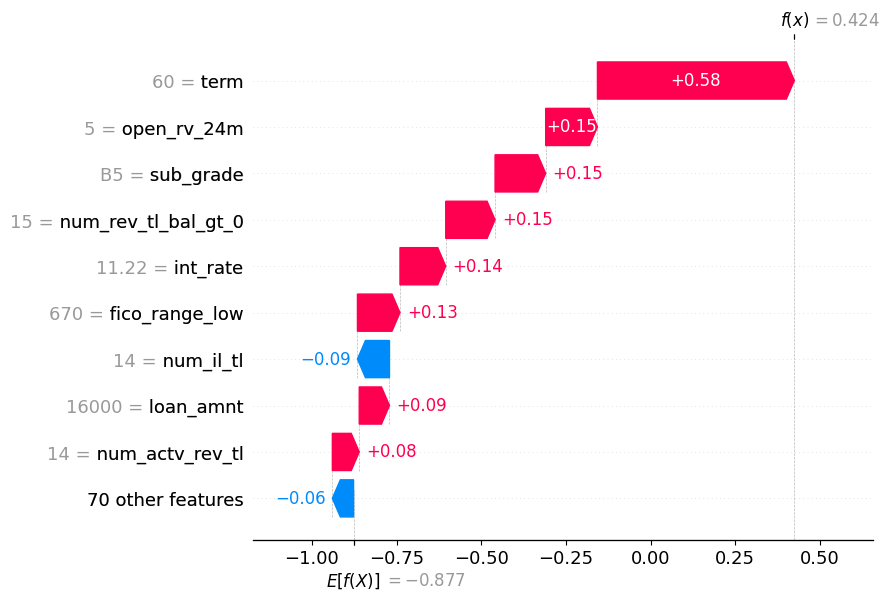

In [44]:
import shap

# Let's explain the prediction for the FIRST person in our test set
applicant_index = 0
single_applicant = X_test_sample.iloc[[applicant_index]]

# 1. Calculate SHAP values for this one person
shap_values_single = explainer.shap_values(single_applicant)

# Extract just the positive class values if it returned a list
if isinstance(shap_values_single, list):
    sv_single_pos = shap_values_single[1][0]
else:
    sv_single_pos = shap_values_single[0]

# 2. Print the actual prediction for this person
prediction = calibrated_model.predict_proba(single_applicant)[0, 1]
print(f"Predicted Default Probability for Applicant #{applicant_index}: {prediction*100:.2f}%")
print(f"Actual Outcome (1=Default, 0=Paid): {y_test.iloc[applicant_index]}")

# 3. Draw the Waterfall Plot
print("\nGenerating SHAP Waterfall Plot...")
shap.waterfall_plot(
    shap.Explanation(
        values=sv_single_pos,
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=single_applicant.iloc[0],
        feature_names=single_applicant.columns.tolist()
    )
)

In [45]:
import joblib

# 1. Save the calibrated model and raw model
joblib.dump(calibrated_model, 'calibrated_model.joblib')
joblib.dump(lgb_sub, 'lgb_raw_model.joblib')

# 2. Save a baseline row of data (the average applicant)
# The app will use this as a template and just update the fields the user changes
baseline_row = X_train.mode().iloc[0]
joblib.dump(baseline_row, 'baseline_row.joblib')

# 3. Save the list of categorical columns so the app knows how to format them
cat_cols = X_train.select_dtypes(include='category').columns.tolist()
joblib.dump(cat_cols, 'cat_cols.joblib')

print("Artifacts saved successfully for Streamlit!")

Artifacts saved successfully for Streamlit!


In [46]:
# Install streamlit and localtunnel
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.9 MB/s eta 0:00:00


In [47]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# --- 1. Load Artifacts ---
@st.cache_resource
def load_artifacts():
    cal_model = joblib.load('calibrated_model.joblib')
    raw_model = joblib.load('lgb_raw_model.joblib')
    baseline = joblib.load('baseline_row.joblib')
    cat_cols = joblib.load('cat_cols.joblib')
    return cal_model, raw_model, baseline, cat_cols

cal_model, raw_model, baseline, cat_cols = load_artifacts()

# --- 2. Build the UI ---
st.set_page_config(page_title="Credit Risk App", layout="wide")
st.title("🏦 Credit Risk Default Predictor")
st.markdown("Enter the applicant's details below to predict their probability of default.")

col1, col2, col3 = st.columns(3)

with col1:
    loan_amnt = st.slider("Loan Amount ($)", 1000, 40000, 15000, step=500)
    int_rate = st.slider("Interest Rate (%)", 5.0, 30.0, 12.0, step=0.1)
    term = st.selectbox("Term (months)", [36, 60])

with col2:
    annual_inc = st.slider("Annual Income ($)", 20000, 200000, 65000, step=5000)
    dti = st.slider("Debt-to-Income Ratio (%)", 0.0, 40.0, 18.0, step=0.5)
    emp_length = st.slider("Employment Length (years)", 0, 10, 4)

with col3:
    grade = st.selectbox("Grade", ['A', 'B', 'C', 'D', 'E', 'F', 'G'])
    purpose = st.selectbox("Purpose", ['debt_consolidation', 'credit_card', 'home_improvement', 'major_purchase', 'other'])

# --- 3. Button to Predict ---
if st.button("Predict Default Risk", type="primary", use_container_width=True):

    # 1. Start with the baseline row (has all 79 columns)
    applicant_data = baseline.copy()

    # 2. Update the values with what the user entered
    applicant_data['loan_amnt'] = float(loan_amnt)
    applicant_data['int_rate'] = float(int_rate)
    applicant_data['term'] = float(term)
    applicant_data['annual_inc'] = float(annual_inc)
    applicant_data['dti'] = float(dti)
    applicant_data['emp_length'] = float(emp_length)
    applicant_data['grade'] = grade
    applicant_data['purpose'] = purpose
    applicant_data['sub_grade'] = grade + '1'

    # 3. Convert to DataFrame
    X_new = pd.DataFrame([applicant_data])

    # 4. Cast categorical columns safely (This is the fix!)
    for c in cat_cols:
        X_new[c] = X_new[c].astype('category')

    # 5. Make Prediction
    proba_default = cal_model.predict_proba(X_new)[0, 1]

    # 6. Display Result
    st.divider()
    col_res1, col_res2 = st.columns([1, 1])

    with col_res1:
        st.metric(label="Predicted Probability of Default", value=f"{proba_default*100:.2f}%")
        if proba_default > 0.20:
            st.error("🚨 High Risk: Applicant is likely to default. Decline.")
        else:
            st.success("✅ Low Risk: Applicant is likely to repay. Approve.")

    with col_res2:
        st.markdown("**Why did the model make this decision?**")
        explainer = shap.TreeExplainer(raw_model)
        shap_values = explainer.shap_values(X_new)

        if isinstance(shap_values, list):
            sv_to_plot = shap_values[1][0]
            base_val = explainer.expected_value[1]
        else:
            sv_to_plot = shap_values[0]
            base_val = explainer.expected_value

        shap.plots.waterfall(shap.Explanation(
            values=sv_to_plot,
            base_values=base_val,
            data=X_new.iloc[0],
            feature_names=X_new.columns.tolist()
        ), show=False)
        st.pyplot(plt.gcf())
        plt.clf()

Writing app.py


In [ ]:
# 1. Kill old processes
!pkill streamlit
!pkill -f localtunnel

# 2. Download Cloudflare Tunnel (fast, no account needed)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# 3. Start Streamlit in the background
!nohup streamlit run app.py --server.port 8500 &>/content/logs.txt &
import time
time.sleep(5) # Wait for Streamlit to wake up

# 4. Start Cloudflare Tunnel
!./cloudflared tunnel --url http://localhost:8500

2026-09-23T14:13:59Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-23T14:13:59Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-23T14:14:04Z INF +--------------------------------------------------------------------------------------------+
2026-09-23T14:14:04Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-23T14:14:04Z INF |  https://expressed-reduced-investigators-intersection.